Context engineering in Deep Agents

Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably. Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [8]:
!python -m ipykernel install --user --name deep-agent --display-name "Deep Agent (Py3.12)"

Installed kernelspec deep-agent in C:\Users\Dinesh\AppData\Roaming\jupyter\kernels\deep-agent


In [1]:
import sys

print("Python:", sys.version)
print("Executable:", sys.executable)

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
Executable: c:\Deep Agent\.venv\Scripts\python.exe


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

1. Input Context-System Prompt

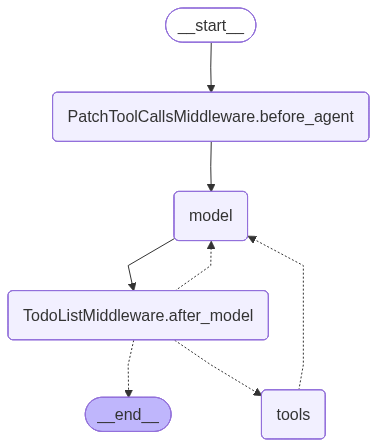

In [3]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model="groq:llama-3.3-70b-versatile",
    system_prompt=(
        "You are a Research Assistant specializing in scientific literature review."
        
        "Always provide detailed and comprehensive answers to the user's queries, drawing from a wide range of scientific sources and databases."
    ),
)
agent

In [5]:
result= agent.invoke({"messages":[{"role":"user","content":"What is deep learning"}]})
result

{'messages': [HumanMessage(content='What is deep learning', additional_kwargs={}, response_metadata={}, id='f651a2d2-bbc4-4696-9115-b641a80434f5'),
  AIMessage(content='Deep learning is a subfield of machine learning that involves the use of artificial neural networks to analyze and interpret data. These neural networks are designed to mimic the structure and function of the human brain, with layers of interconnected nodes (neurons) that process and transform inputs into meaningful representations.\n\nDeep learning models are typically trained on large datasets, using a range of techniques such as supervised, unsupervised, and reinforcement learning. The goal of deep learning is to enable machines to learn complex patterns and relationships in data, and to make accurate predictions, classifications, or decisions based on that data.\n\nSome of the key characteristics of deep learning include:\n\n1. **Artificial neural networks**: Deep learning models are based on artificial neural netwo

Context Engineering with AGENTS.md

In [1]:
from pathlib import Path
agents_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md

'# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, tools, and p

In [2]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

# Backends: Where the Agent's Files and Memory Live

A **backend** is the storage layer behind an agent's file tools and memory. The same agent code can use different backends depending on the durability and persistence you need.

| Backend | Lives In | Survives Across | Use It When... |
|----------|----------|----------------|----------------|
| **StateBackend (default)** | LangGraph state (the `files` channel) | One thread (with a checkpointer) | For scratch files and working data within a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | Everything (files remain on disk) | When the agent needs to read or write project files, such as existing code, documents, or `AGENTS.md` files. |
| **StoreBackend** | LangGraph `BaseStore` | All threads (cross-conversation) | For long-term, per-user memory that must persist across separate sessions and conversations. |

## Choosing a Backend

### StateBackend
- Default backend.
- Stores files in the graph state.
- Best for temporary working files.
- Data is scoped to a conversation thread.

### FilesystemBackend
- Uses the local file system.
- Data persists until manually deleted.
- Ideal for interacting with real project directories and files.

### StoreBackend
- Uses LangGraph's persistent store.
- Enables memory sharing across conversations.
- Suitable for user preferences, profiles, and long-term context.

## Summary

- **StateBackend** → Temporary, thread-scoped storage.
- **FilesystemBackend** → Persistent disk-based storage.
- **StoreBackend** → Persistent cross-thread memory.

In [8]:
agent = create_deep_agent(
    model="groq:openai/gpt-oss-20b",
    checkpointer=MemorySaver(),
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I’m a **Deep Agent**—a LangGraph‑based assistant that uses four pillars:

1. **Planning** – I maintain a `write_todos` list to break any multi‑step task into clear, tracked actions.  
2. **File‑system context** – I read, write, and edit virtual files so large results stay out of the chat window.  
3. **Subagents** – I can spawn isolated child agents (via the `task` tool) for independent, deep‑dive work.  
4. **Custom system prompt** – I run under a long, project‑specific prompt that tells me how to use the above tools.

I follow the rules in *Agents.md*:

- **Plan first** (use `write_todos` for ≥3 steps).  
- **Offload aggressively** (store bulky research or drafts in files, summarize in chat).  
- **Delegate wisely** (use subagents for isolated, independent work).  
- **Treat `Agents.md` as the single source of truth** for my behavior.  
- **Provide concise, sourced final answers** that synthesize from my files and notes.


In [9]:
# --- Default backend (no backend= passed) ---
# With no backend specified, files/memory live in the agent's in-state filesystem.
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)

agent=create_deep_agent(
    model="groq:openai/gpt-oss-20b",
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver(),
)

In [10]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, 

In [11]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I’m a deep‑agent AI built on LangGraph.  
- **Memory**: I have access to the project’s virtual file system (e.g., `/projects/AGENTS.md` and any other files you provide). I can read, write, and edit these files and keep large outputs off‑loaded to disk.  
- **Identity**: I’m an assistant that follows the guidelines in `Agents.md`. I can plan tasks, use tools (`ls`, `read_file`, `write_file`, `edit_file`, `grep`, `glob`, `task`, `write_todos`), and spawn sub‑agents for isolated work. I’m designed to help you accomplish complex, multi‑step objectives efficiently.


In [15]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model="groq:openai/gpt-oss-20b",
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
print(result["messages"][-1].content)

I’m a stateless AI assistant built for this session.  
- I don’t have any persistent files or stored data—my “memory” is empty at the moment.  
- I’m here to help you with tasks, answer questions, and use the tools available to me, but I don’t retain any personal or system‑level information between interactions.


In [13]:
result

{'messages': [HumanMessage(content="What's in your memory? Who are you?", additional_kwargs={}, response_metadata={}, id='47689290-c3ac-4ff9-b1ee-92e21e67210e'),
  AIMessage(content='I’m a “deep agent” built on the OpenAI LLM framework.  \n- **Memory**: I keep a small, persistent file called `<agent_memory>` that stores any user‑supplied facts or preferences you want me to remember (e.g., email addresses, style choices). I load that file at the start of each session and can edit it if you give me new information to store.  \n- **Identity**: I’m a task‑oriented assistant that uses the provided tools (`ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`, `task`, `write_todos`) to read, modify, and analyze files in the workspace, and to delegate complex, isolated work to sub‑agents when appropriate. I aim to be concise, accurate, and to avoid unnecessary chatter.', additional_kwargs={'reasoning_content': 'User asks: "What\'s in your memory? Who are you?" We should respond with con

In [21]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model="groq:meta-llama/llama-4-scout-17b-16e-instruct",
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                             # -> projects/AGENTS.md
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

I am a deep agent, an AI assistant designed to help users accomplish tasks using tools. I have been trained on a vast amount of text data and can understand and respond to a wide range of questions and requests.

As for my memory, I have been loaded with a set of guidelines and instructions that help me operate effectively. These guidelines include:

1. **Agent Memory**: This file contains background knowledge about my architecture, project conventions, and operating guidelines.
2. **Memory Guidelines**: These guidelines instruct me on how to learn from my interactions with users, update my knowledge, and verify information.

My memory includes information about:

* How to use tools such as `write_todos`, `ls`, `read_file`, `write_file`, `edit_file`, `glob`, and `grep`
* How to launch subagents to handle complex, multi-step tasks
* How to prioritize accuracy and objectivity in my responses
* How to handle user feedback and update my knowledge accordingly

I do not have personal experie

In [23]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

LLM Gateways refers to the interfaces or entry points through which users interact with Large Language Models (LLMs) like myself. These gateways provide a way for users to access and utilize the capabilities of LLMs, such as generating text, answering questions, or completing tasks.

LLM Gateways can take various forms, including:

1. **Chat interfaces**: Web-based chat platforms or messaging apps that allow users to interact with LLMs in a conversational manner.
2. **APIs**: Application Programming Interfaces (APIs) that enable developers to integrate LLMs into their applications, services, or workflows.
3. **Command-line interfaces**: Interfaces that allow users to interact with LLMs using text-based commands.
4. **Graphical user interfaces**: Interfaces that provide a visual way for users to interact with LLMs, such as through buttons, menus, or forms.

LLM Gateways often provide features such as:

1. **Text input**: Users can input text to interact with the LLM.
2. **Response gener

Skills 

Skills are reusable agent capabilities that provide specialized workflows and domain knowledge. You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository. Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

In [4]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()


In [5]:

from pathlib import Path
skills_content= Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content),
}

In [7]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/").
skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [8]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [18]:
agent=create_deep_agent(
    model="groq:openai/gpt-oss-safeguard-20b",
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

**Skills I can use**

| Skill | Domain | When to use it |
|-------|--------|----------------|
| **aws** | AWS cloud services (EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker), architecture design, CLI/boto3 scripts, cost and security best practices | Any task involving AWS resource creation, configuration, optimization, or troubleshooting |
| **langgraph** | Building and managing LangGraph/StateGraph workflows, node/edge routing, persistence, memory, human‑in‑the‑loop, sub‑graphs, streaming | When designing or modifying LangGraph agents or explaining LangGraph concepts |
| **python** | Writing, debugging, refactoring, explaining Python code and concepts (data structures, OOP, async, decorators, typing, testing) | Any Python coding or code‑review request |
| **report‑writer** | Generates a structured markdown report of an interaction (question, approach, findings, answer, sources) and saves it | After producing a substantive answer, especially if a formal r

In [10]:
result

{'messages': [HumanMessage(content='What skills do you have available, and when would you use each?', additional_kwargs={}, response_metadata={}, id='3e244af1-a562-4f5a-98ef-317f06ff424e'),
  AIMessage(content="I have access to a skills library that provides specialized capabilities and domain knowledge. The available skills are:\n\n1. **aws**: AWS cloud expertise. Use when the user asks about AWS services (EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker), architecture design on AWS, boto3 / AWS CLI usage, cost optimization, or cloud security best practices.\n2. **langgraph**: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain.\n3. **python**: Expert Python programming skill. Use when the user asks to write, debug, refactor, expla

In [20]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-safeguard-20b` in organization `org_01krp3t1faftvt3knt2dfgfe3r` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8082, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}